# Pré-entraînement auto-supervisé (SSL) puis fine-tuning (Fashion-MNIST)

Même protocole que le notebook 02 original, sur T-shirt/top vs Shirt (Fashion-MNIST) au lieu du
cancer du sein. D'abord un pré-entraînement sans labels (juste reconstruire), puis je récupère
l'encodeur pour classer, en comparant deux régimes :

- linear probing : encodeur gelé, on n'entraîne qu'une petite tête
- full fine-tuning : on repart des mêmes poids mais tout le réseau s'adapte

Et à la fin je regarde ce que ça change de faire varier la dimension de l'espace latent — c'est
la question la plus intéressante ici, puisque sur le cancer ça ne changeait presque rien.

In [1]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123

def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

## Données

Fashion-MNIST limité à T-shirt/top (`0`) et Shirt (`1`, anomalie/positif). Découpage 60 / 20 / 20
comme l'original. Le pré-entraînement utilise le train sans labels, la classification le train
avec labels.

In [2]:
data = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")
X_all, y_all = data.data, data.target.astype(int)

mask = np.isin(y_all, [0, 6])
X = X_all[mask]
y = (y_all[mask] == 6).astype(int)  # 0 = T-shirt/top, 1 = Shirt
target_names = np.array(["T-shirt/top", "Shirt"])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(X_train.shape, X_val.shape, X_test.shape)

(8400, 784) (2800, 784) (2800, 784)


In [3]:
Xtr = torch.from_numpy(X_train).float()
Xva = torch.from_numpy(X_val).float()
Xte = torch.from_numpy(X_test).float()
ytr = torch.from_numpy(y_train).long()
yva = torch.from_numpy(y_val).long()
yte = torch.from_numpy(y_test).long()

# batch_size 128 (vs 64 sur le cancer) : dataset ~15x plus gros
pretrain_loader = DataLoader(TensorDataset(Xtr), batch_size=128, shuffle=True)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=128, shuffle=False)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=128, shuffle=False)

## Le modèle

Même auto-encodeur qu'au notebook 01 (784 -> 256 -> 64 -> latent), dimension latente en
paramètre pour le sweep plus loin.

In [4]:
class Encodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 64),
            nn.LeakyReLU(),
            nn.Linear(64, latent_dim),
        )
    def forward(self, x):
        return self.net(x)

class Decodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 784),
        )
    def forward(self, z):
        return self.net(z)

class AutoEncodeur(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(latent_dim)
        self.decodeur = Decodeur(latent_dim)
    def forward(self, x):
        return self.decodeur(self.encodeur(x))

class Classifieur(nn.Module):
    def __init__(self, encodeur, latent_dim, freeze):
        super().__init__()
        self.encodeur = encodeur
        if freeze:
            for p in self.encodeur.parameters():
                p.requires_grad = False
        self.tete = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.LeakyReLU(),
            nn.Linear(8, 2),
        )
    def forward(self, x):
        return self.tete(self.encodeur(x))

## Fonctions d'entraînement

Comme dans l'original : je factorise le pré-entraînement, l'entraînement de la classif et
l'évaluation.

In [5]:
def pretrain(latent_dim, epochs=80):
    set_seed()
    ae = AutoEncodeur(latent_dim)
    loss_fn = nn.MSELoss()
    opt = torch.optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-4)
    for _ in range(epochs):
        ae.train()
        for (xb,) in pretrain_loader:
            opt.zero_grad()
            loss = loss_fn(ae(xb), xb)
            loss.backward()
            opt.step()
    return ae

def train_clf(model, epochs=80, verbose=False):
    loss_fn = nn.CrossEntropyLoss()
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if verbose and (epoch + 1) % 20 == 0:
            acc = eval_acc(model, val_loader)
            print("epoch", epoch + 1, "val acc", round(acc, 3))
    return model

def eval_acc(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += len(yb)
    return correct / total

def test_scores(model):
    model.eval()
    yt, yp, pp = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            pp.extend(torch.softmax(logits, dim=1)[:, 1].numpy())
            yp.extend(logits.argmax(dim=1).numpy())
            yt.extend(yb.numpy())
    yt, yp, pp = np.array(yt), np.array(yp), np.array(pp)
    return {"f1": f1_score(yt, yp, average="macro"), "auc": roc_auc_score(yt, pp), "yt": yt, "yp": yp}

## Pré-entraînement (latent = 2)

In [6]:
ae = pretrain(latent_dim=2)

## Linear probing

In [7]:
set_seed()
probe = Classifieur(copy.deepcopy(ae.encodeur), latent_dim=2, freeze=True)
train_clf(probe, verbose=True)

r_probe = test_scores(probe)
print()
print("F1 macro:", round(r_probe["f1"], 3), "| ROC-AUC:", round(r_probe["auc"], 3))
print(classification_report(r_probe["yt"], r_probe["yp"], target_names=target_names))

epoch 20 val acc 0.794


epoch 40 val acc 0.792


epoch 60 val acc 0.798


epoch 80 val acc 0.8

F1 macro: 0.796 | ROC-AUC: 0.867
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.92      0.82      1400
       Shirt       0.89      0.68      0.77      1400

    accuracy                           0.80      2800
   macro avg       0.82      0.80      0.80      2800
weighted avg       0.82      0.80      0.80      2800



## Full fine-tuning

On repart des mêmes poids pré-entraînés (deepcopy) mais cette fois rien n'est gelé.

In [8]:
set_seed()
ft = Classifieur(copy.deepcopy(ae.encodeur), latent_dim=2, freeze=False)
train_clf(ft, verbose=True)

r_ft = test_scores(ft)
print()
print("F1 macro:", round(r_ft["f1"], 3), "| ROC-AUC:", round(r_ft["auc"], 3))
print(confusion_matrix(r_ft["yt"], r_ft["yp"]))

epoch 20 val acc 0.859


epoch 40 val acc 0.871


epoch 60 val acc 0.87


epoch 80 val acc 0.86

F1 macro: 0.855 | ROC-AUC: 0.938
[[1154  246]
 [ 159 1241]]


## Comparaison des deux régimes

In [9]:
def n_trainable(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("linear probing  -> params entraines:", n_trainable(probe),
      "| F1:", round(r_probe["f1"], 3), "| AUC:", round(r_probe["auc"], 3))
print("full fine-tuning-> params entraines:", n_trainable(ft),
      "| F1:", round(r_ft["f1"], 3), "| AUC:", round(r_ft["auc"], 3))

linear probing  -> params entraines: 42 | F1: 0.796 | AUC: 0.867
full fine-tuning-> params entraines: 217580 | F1: 0.855 | AUC: 0.938


## Effet de la dimension de l'espace latent

Sur le cancer, faire varier le latent ne changeait presque rien (déjà proche du plafond dès la
dimension 2). Ici, avec 784 pixels en entrée, la dimension 2 est probablement un goulot bien
plus serré. Je relance tout le pipeline (pré-entraînement + probing + full fine-tuning) pour
plusieurs dimensions latentes et je regarde comment évoluent le F1 et le ROC-AUC sur le test.

In [10]:
dims = [2, 4, 8, 16, 32]
rows = []
for d in dims:
    ae_d = pretrain(latent_dim=d)

    set_seed()
    p = Classifieur(copy.deepcopy(ae_d.encodeur), latent_dim=d, freeze=True)
    train_clf(p)
    rp = test_scores(p)

    set_seed()
    f = Classifieur(copy.deepcopy(ae_d.encodeur), latent_dim=d, freeze=False)
    train_clf(f)
    rf = test_scores(f)

    rows.append([d, round(rp["auc"], 3), round(rp["f1"], 3), round(rf["auc"], 3), round(rf["f1"], 3)])
    print("latent", d, "ok")

res = pd.DataFrame(rows, columns=["latent_dim", "probe_auc", "probe_f1", "ft_auc", "ft_f1"])
res

latent 2 ok


latent 4 ok


latent 8 ok


latent 16 ok


latent 32 ok


,latent_dim,probe_auc,probe_f1,ft_auc,ft_f1
0,2,0.867,0.798,0.941,0.869
1,4,0.882,0.806,0.935,0.865
2,8,0.918,0.835,0.940,0.877
3,16,0.931,0.850,0.938,0.864
4,32,0.925,0.845,0.940,0.870


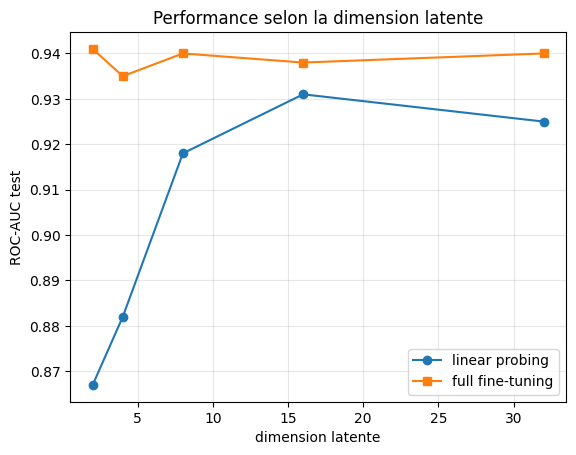

In [11]:
plt.plot(res["latent_dim"], res["probe_auc"], "o-", label="linear probing")
plt.plot(res["latent_dim"], res["ft_auc"], "s-", label="full fine-tuning")
plt.xlabel("dimension latente"); plt.ylabel("ROC-AUC test"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Performance selon la dimension latente")
plt.savefig("figures/latent_dim_sweep.png", dpi=130, bbox_inches="tight")
plt.show()

## Bilan

Contrairement au cancer (où la dimension latente ne changeait presque rien), ici la dimension
latente compte vraiment pour le linear probing : ROC-AUC 0,867 en latent 2, qui monte à 0,918
en latent 8 et plafonne autour de 0,93 à partir de la dimension 16. Logique — compresser 784
pixels à 2 dimensions perd beaucoup plus d'information que compresser 30 variables déjà
redondantes. Le full fine-tuning, lui, reste stable autour de 0,935-0,94 quel que soit le
latent (0,941 en dim 2 jusqu'à 0,94 en dim 32) : en réentraînant tout le réseau, il compense un
goulot d'étranglement étroit, alors que le probing en dépend directement puisque l'encodeur est
gelé.

Autre différence avec le cancer : ici le full fine-tuning (AUC ~0,94) dépasse nettement le
linear probing en dimension 2 (AUC 0,867) — l'écart est objectivement plus large que sur les
30 variables tabulaires du cancer, où les deux régimes se tenaient à 1-2 points près. C'est le
genre de dataset où le pré-entraînement a vraiment de quoi apporter quelque chose : à comparer
maintenant aux baselines supervisées du notebook 03, qui n'ont accès qu'aux pixels bruts sans
aucune notion de structure d'image.